Hyperparameter tuning is basically trying and testing multiple hyperparameters and selecting the best one for given data

In keras we use `keras-tuner`

This is a binary classification dataset, where we have to predict if someone has diabeties (1) or not (0)

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import Sequential
from keras.layers import Input, Dense

import keras_tuner
from keras.optimizers import SGD

In [26]:
data = pd.read_csv('dataset/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [29]:
#Separate data
X, y = data.iloc[:,:-1], data.iloc[:,-1]

In [50]:
#Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

### Selecting optimizer

In [126]:
#Define function
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    #Give choices
    optimizer = hp.Choice('optimizer',values=['adam', 'sgd', 'rmsprop']) 

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

#Define tuner
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,     
    directory = 'optimizer',
    project_name = 'optimizer_selection'
    )


#Test
tuner.search(X_train,y_train,epochs=10,validation_data=(X_test,y_test),verbose=1)

Reloading Tuner from optimizer\optimizer_selection\tuner0.json


The tuner built 3 models and ran them for 5 epochs and below are results based on that 

In [127]:
#Get summary
tuner.results_summary()

Results summary
Results in optimizer\optimizer_selection
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
optimizer: rmsprop
Score: 0.7467532753944397

Trial 02 summary
Hyperparameters:
optimizer: adam
Score: 0.7272727489471436

Trial 00 summary
Hyperparameters:
optimizer: sgd
Score: 0.7077922224998474


In [128]:
#Get best hyparameter value
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [129]:
#Get best model
print(tuner.get_best_models(num_models=1))
type(tuner.get_best_models(num_models=1))

c:\Users\Arun\Documents\Documents\Deep Learning\env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


[<Sequential name=sequential, built=True>]


list

In [130]:
#Train the model based on best hyperparameter model
model = tuner.get_best_models(num_models=1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
history = model.fit(
    X_train,y_train, 
    epochs=100, 
    initial_epoch=6, #Because 5 epochs are already done during searching
    batch_size=32,
    verbose=1,
    validation_data = (X_test,y_test)
    )

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7524 - loss: 0.5702 - val_accuracy: 0.7208 - val_loss: 0.5844
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7704 - loss: 0.5430 - val_accuracy: 0.7208 - val_loss: 0.5729
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7671 - loss: 0.5234 - val_accuracy: 0.7338 - val_loss: 0.5648
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7752 - loss: 0.5081 - val_accuracy: 0.7403 - val_loss: 0.5564
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7720 - loss: 0.4962 - val_accuracy: 0.7468 - val_loss: 0.5509
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7785 - loss: 0.4869 - val_accuracy: 0.7403 - val_loss: 0.5446
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7801 - loss: 0.4790 - val_accuracy: 0.7468 - val_loss: 0.5409
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7866 - loss: 0.4731 - val_accuracy: 0.74

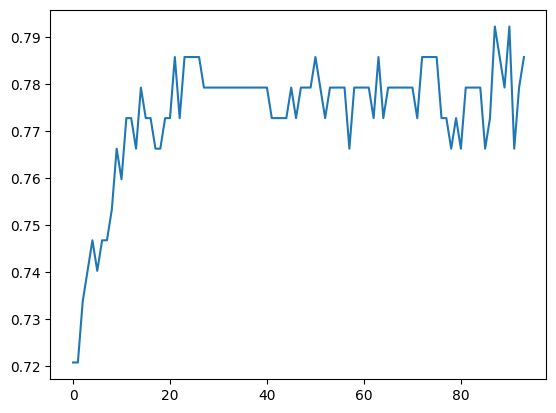

In [132]:
plt.plot(history.history['val_accuracy'])

Clearly we can do many improvements here like batch norm, dropout, callbacks 

### Selecting number of neurons and layers

In [136]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    
    units = hp.Int('units', min_value=16, max_value=256, step=8)
    model.add(Dense(units=units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
    return model

tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='neurons',
    project_name='neuron_selection'
)

tuner.search(X_train,y_train, epochs=20,validation_data=(X_test,y_test),verbose=1)

Reloading Tuner from neurons\neuron_selection\tuner0.json


In [137]:
tuner.get_best_hyperparameters()[0].values

{'units': 160}

In [138]:
model = tuner.get_best_models(num_models=1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 160)            │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

In [139]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,initial_epoch=11)

Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7948 - loss: 0.4226 - val_accuracy: 0.7727 - val_loss: 0.5175
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8046 - loss: 0.4173 - val_accuracy: 0.7662 - val_loss: 0.5208
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8062 - loss: 0.4165 - val_accuracy: 0.7662 - val_loss: 0.5170
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8013 - loss: 0.4161 - val_accuracy: 0.7597 - val_loss: 0.5195
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8062 - loss: 0.4143 - val_accuracy: 0.7727 - val_loss: 0.5241
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8111 - loss: 0.4131 - val_accuracy: 0.7662 - val_loss: 0.5223
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8094 - loss: 0.4122 - val_accuracy: 0.7597 - val_loss: 0.5174
Epoch 19/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8013 - loss: 0.4101 - val_accuracy: 0

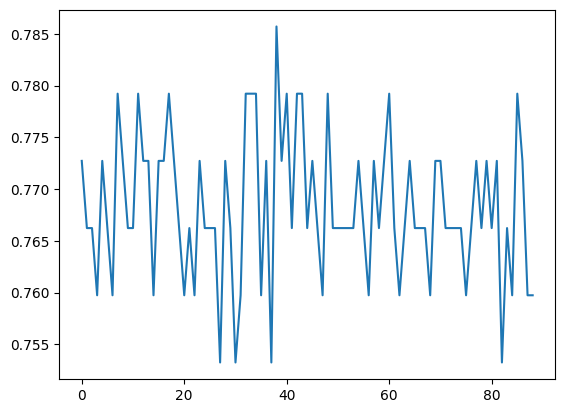

In [140]:
plt.plot(history.history['val_accuracy'])

### Selecting number of layers

In [145]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    #how this loop works:
    #For n_th iteration, we get a model with n layers
    #Ex: In 2nd iteration we have model with 2 layers
    for i in range(hp.Int('num_layers',min_value=1, max_value=10)):
        model.add(Dense(units=160, activation='relu'))

    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='rmsprop',loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='num_layers',
    project_name = 'num_layers_selection'
)

tuner.search(X_train, y_train, validation_data=(X_test,y_test), epochs=10)

Reloading Tuner from num_layers\num_layers_selection\tuner0.json


In [146]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 6}

In [148]:
model = tuner.get_best_models(num_models=1)[0]

In [149]:
history = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=100,initial_epoch=11)

Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7590 - loss: 0.4729 - val_accuracy: 0.7727 - val_loss: 0.6336
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7964 - loss: 0.4371 - val_accuracy: 0.7597 - val_loss: 0.5766
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7964 - loss: 0.4294 - val_accuracy: 0.7727 - val_loss: 0.5181
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7899 - loss: 0.4082 - val_accuracy: 0.7597 - val_loss: 0.5827
Epoch 16/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7932 - loss: 0.3982 - val_accuracy: 0.7273 - val_loss: 0.5539
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8160 - loss: 0.3787 - val_accuracy: 0.7078 - val_loss: 0.5802
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8274 - loss: 0.3755 - val_accuracy: 0.7468 - val_loss: 0.6248
Epoch 19/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8371 - loss: 0.3628 - val_accuracy: 0

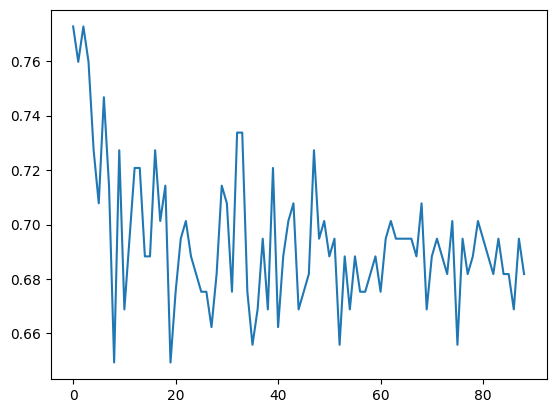

In [150]:
plt.plot(history.history['val_accuracy'])

some pretty bad overfitting

### Searching for all hyperparameters together

In [157]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for i in range(hp.Int('num_layer',min_value=1,max_value=10)):
        
        model.add(Dense(
            units = hp.Int('units'+str(i), min_value=8,max_value=128,step=8),
            activation=hp.Choice('activation' + str(i), ['relu','tanh','selu']))
            )
    
    model.add(Dense(1, activation='sigmoid'))
    optimizer = hp.Choice('optimizer',['rmsprop','adam','sgd'])
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    return model


tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='final_tuning',
    project_name="final"
)

In [159]:
tuner.search(X_train,y_train,validation_data=(X_test,y_test),epochs=10)

In [162]:
tuner.get_best_hyperparameters()[0].values

{'num_layer': 2,
 'units0': 120,
 'activation0': 'selu',
 'optimizer': 'sgd',
 'units1': 24,
 'activation1': 'relu',
 'units2': 32,
 'activation2': 'selu',
 'units3': 48,
 'activation3': 'tanh',
 'units4': 24,
 'activation4': 'selu'}

In [163]:
model = tuner.get_best_models()[0]

In [167]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=300,initial_epoch=10)

Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8176 - loss: 0.3908 - val_accuracy: 0.7532 - val_loss: 0.5309
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8176 - loss: 0.3906 - val_accuracy: 0.7532 - val_loss: 0.5301
Epoch 13/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8208 - loss: 0.3903 - val_accuracy: 0.7532 - val_loss: 0.5275
Epoch 14/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8143 - loss: 0.3902 - val_accuracy: 0.7792 - val_loss: 0.5246
Epoch 15/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8160 - loss: 0.3902 - val_accuracy: 0.7727 - val_loss: 0.5257
Epoch 16/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8143 - loss: 0.3900 - val_accuracy: 0.7727 - val_loss: 0.5258
Epoch 17/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8225 - loss: 0.3900 - val_accuracy: 0.7532 - val_loss: 0.5287
Epoch 18/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8208 - loss: 0.3895 - val_accuracy: 0.

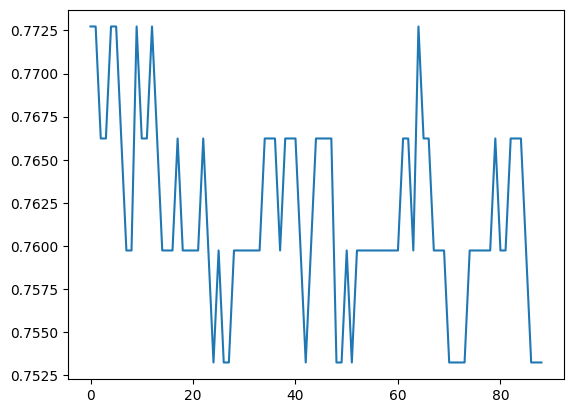

In [166]:
plt.plot(history.history['val_accuracy'])